# ACC102 Track4 Assignment: Apple Inc. (AAPL) Financial & Market Performance Analysis
**Student ID: 2470786**
**Date: 2026-04-23**

## 1. Library Import & WRDS Database Connection

In [1]:
# 'import' Loads an external library so we can use its functions in this notebook
# 'wrds'  connects Python to the WRDS financial database server.
# 'pandas' (nicknamed 'pd') is the main library for working with data tables
import wrds
import pandas as pd

In [2]:
# Replace the string below with your own WRDS account name (e.g. 'jsmith')
username = "elena9522"

# wrds.Connection() opens a Live connection to the WRDS database server
# We store the connection object in 'db' so every later query can reuse it
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


## 2. Target Company Identifier (GVKEY) Acquisition

In [4]:
# Define target company ticker (AAPL = Apple Inc.)
target_ticker = "AAPL"

print(f"Fetching GVKEY for {target_ticker}...")
# Use comp.funda table (you will reuse this table for financial data later)
# This table 100% has tic and gvkey columns, eliminates the missing column error
gvkey_query = f"""
SELECT DISTINCT gvkey, conm, tic
FROM comp.funda
WHERE tic = '{target_ticker}'
AND indfmt = 'INDL'
AND datafmt = 'STD'
AND popsrc = 'D'
AND consol = 'C'
LIMIT 1
"""
company_info = db.raw_sql(gvkey_query)

# Extract GVKEY and company full name for later use
target_gvkey = company_info['gvkey'].iloc[0]
company_full_name = company_info['conm'].iloc[0]

print(f"✅ Company identified: {company_full_name}")
print(f"✅ Compustat GVKEY: {target_gvkey}")

Fetching GVKEY for AAPL...
✅ Company identified: APPLE INC
✅ Compustat GVKEY: 001690


In [5]:
print(f"GVKEY is ready: {target_gvkey}")
print(f"Company name is ready: {company_full_name}")

GVKEY is ready: 001690
Company name is ready: APPLE INC


## 3. Financial Statement Data Collection (Compustat)

In [6]:
print("Fetching financial statements from Compustat...")
# SQL query to pull core financial statement data for AAPL
financial_sql = f"""
SELECT 
    fyear as fiscal_year,
    revt as total_revenue,
    gp as gross_profit,
    ni as net_income,
    at as total_assets,
    act as current_assets,
    lct as current_liabilities,
    lt as total_liabilities,
    seq as stockholders_equity
FROM comp.funda
WHERE 
    gvkey = '{target_gvkey}'
    AND indfmt = 'INDL'
    AND datafmt = 'STD'
    AND popsrc = 'D'
    AND consol = 'C'
    AND fyear >= {pd.Timestamp.now().year - 4}
ORDER BY fyear DESC
"""
financial_data = db.raw_sql(financial_sql)
financial_data = financial_data.set_index('fiscal_year')

# Split into Income Statement and Balance Sheet
income_statement = financial_data[['total_revenue', 'gross_profit', 'net_income']].rename(columns={
    'total_revenue': 'Total Revenue',
    'gross_profit': 'Gross Profit',
    'net_income': 'Net Income'
})

balance_sheet = financial_data[['total_assets', 'current_assets', 'current_liabilities', 'total_liabilities', 'stockholders_equity']].rename(columns={
    'total_assets': 'Total Assets',
    'current_assets': 'Current Assets',
    'current_liabilities': 'Current Liabilities',
    'total_liabilities': 'Total Liabilities',
    'stockholders_equity': 'Stockholders Equity'
})

print("✅ Financial statements fetched successfully!")
print("\n📊 Income Statement Preview:")
print(income_statement)

Fetching financial statements from Compustat...
✅ Financial statements fetched successfully!

📊 Income Statement Preview:
             Total Revenue  Gross Profit  Net Income
fiscal_year                                         
2025              416161.0      203201.0    112010.0
2024              391035.0      188883.0     93736.0
2023              383285.0      177648.0     96995.0
2022              394328.0      179482.0     99803.0


## 4. Stock Data Identifier (PERMNO) Acquisition

In [9]:
# Safely get PERMNO: take the first record if multiple exist
if len(check_permno_data) > 0:
    target_permno = check_permno_data['permno'].iloc[0]
    company_name_crsp = check_permno_data['comnam'].iloc[0]
    print(f"✅ CRSP PERMNO found: {target_permno}")
    print(f"✅ Company name in CRSP: {company_name_crsp}")
else:
    print("❌ No records found for AAPL in CRSP. Check your WRDS permissions.")

✅ CRSP PERMNO found: 14593
✅ Company name in CRSP: APPLE INC


## 5. Daily Stock Trading Data Collection (CRSP)

In [11]:
print("Fetching 5 years of stock price data from CRSP...")

price_sql = f"""
SELECT 
    date,
    prc as Close,
    vol as Volume
FROM crsp.dsf
WHERE 
    permno = {target_permno}
    AND date >= '2020-01-01'
    AND date <= '2024-12-31'
ORDER BY date ASC
"""
stock_price_data = db.raw_sql(price_sql)
stock_price_data = stock_price_data.set_index('date')

print("✅ Stock price data fetched successfully!")

print(f"📊 Data range: {stock_price_data.index.min()} to {stock_price_data.index.max()}")
print(f"📊 Total trading days: {len(stock_price_data)}")

Fetching 5 years of stock price data from CRSP...
✅ Stock price data fetched successfully!
📊 Data range: 2020-01-02 to 2024-12-31
📊 Total trading days: 1258


In [12]:
print("📊 Stock price data preview:")
print(stock_price_data.head())

📊 Stock price data preview:
                close      volume
date                             
2020-01-02  300.35001  33884314.0
2020-01-03  297.42999  36604600.0
2020-01-06  299.79999  29597401.0
2020-01-07  298.39001  27864170.0
2020-01-08  303.19000  33060420.0


## Data & Methodology
1.  **Data Source**: All financial statement data is sourced from the WRDS Compustat North America Funda database, covering Apple Inc.'s 2022-2025 fiscal year consolidated financial statements. All stock trading data is sourced from the WRDS CRSP Daily Stock File (dsf), covering 2020-2024 daily trading data.
2.  **Data Filtering**: We use the standard Compustat screening criteria (`indfmt='INDL'`, `datafmt='STD'`, `popsrc='D'`, `consol='C'`) to ensure we only select industrial-format, standard consolidated financial data for US domestic companies, fully consistent with the course requirements.
3.  **Data Cleaning**: We fill missing values with 0, exclude invalid rows with zero total revenue or total assets, and sort the data by fiscal year in ascending order for trend analysis.

In [13]:
db.close()
print("✅ WRDS connection closed successfully")

✅ WRDS connection closed successfully


## 6. Core Financial Metric Calculation

In [14]:
print("Starting data cleaning and financial metric calculation...")

income_clean = income_statement.fillna(0)
balance_clean = balance_sheet.fillna(0)

price_clean = stock_price_data.dropna(subset=["close", "volume"])


income_clean = income_clean[income_clean["Total Revenue"] != 0]
balance_clean = balance_clean[balance_clean["Total Assets"] != 0]


financial_metrics = pd.DataFrame()

financial_metrics["Gross Profit Margin (%)"] = (
    income_clean["Gross Profit"] / income_clean["Total Revenue"] * 100
)  
financial_metrics["Net Profit Margin (%)"] = (
    income_clean["Net Income"] / income_clean["Total Revenue"] * 100
)  
financial_metrics["Return on Equity (ROE) (%)"] = (
    income_clean["Net Income"] / balance_clean["Stockholders Equity"] * 100
)  
financial_metrics["Return on Assets (ROA) (%)"] = (
    income_clean["Net Income"] / balance_clean["Total Assets"] * 100
)  


financial_metrics["Current Ratio"] = (
    balance_clean["Current Assets"] / balance_clean["Current Liabilities"]
)  
financial_metrics["Debt to Asset Ratio (%)"] = (
    balance_clean["Total Liabilities"] / balance_clean["Total Assets"] * 100
)  


financial_metrics = financial_metrics.sort_index().round(2)


price_clean["Daily Return"] = price_clean["close"].pct_change()  
price_clean["Cumulative Return"] = (1 + price_clean["Daily Return"]).cumprod() - 1 

print("✅ Data processing complete!")
print("\n📊 Final Core Financial Metrics:")
print(financial_metrics)

Starting data cleaning and financial metric calculation...
✅ Data processing complete!

📊 Final Core Financial Metrics:
             Gross Profit Margin (%)  Net Profit Margin (%)  \
fiscal_year                                                   
2022                           45.52                  25.31   
2023                           46.35                  25.31   
2024                           48.30                  23.97   
2025                           48.83                  26.92   

             Return on Equity (ROE) (%)  Return on Assets (ROA) (%)  \
fiscal_year                                                           
2022                             196.96                       28.29   
2023                             156.08                       27.51   
2024                             164.59                       25.68   
2025                             151.91                       31.18   

             Current Ratio  Debt to Asset Ratio (%)  
fiscal_year         

## Definition of Core Financial Metrics
1.  **Gross Profit Margin (%)**
    - Formula: `(Gross Profit / Total Revenue) * 100`
    - Accounting Meaning: Measures the percentage of revenue retained after deducting the cost of goods sold, reflecting the company's core product profitability and cost control ability.
    - For Apple Inc.: The gross profit margin increased from 45.52% in 2022 to 48.83% in 2025, indicating continuous improvement in the company's cost control efficiency.

2.  **Net Profit Margin (%)**
    - Formula: `(Net Income / Total Revenue) * 100`
    - Accounting Meaning: Measures the percentage of revenue retained as net profit after all operating expenses, interest, and taxes, reflecting the company's overall profitability.
    - For Apple Inc.: The net profit margin remained stable at around 23%-27% from 2022 to 2025, showing strong and consistent profit-generating ability.

3.  **Return on Equity (ROE) (%)**
    - Formula: `(Net Income / Stockholders' Equity) * 100`
    - Accounting Meaning: A core metric to measure the return generated for shareholders, reflecting the company's ability to create value for equity investors.
    - For Apple Inc.: ROE consistently exceeded 150% during the period, demonstrating excellent efficiency in using shareholder capital.

4.  **Return on Assets (ROA) (%)**
    - Formula: `(Net Income / Total Assets) * 100`
    - Accounting Meaning: Measures how efficiently the company uses its assets to generate profit, reflecting the overall operational efficiency of the company.
    - For Apple Inc.: ROA stayed above 20% during the period, indicating high efficiency in asset utilization.

5.  **Current Ratio**
    - Formula: `Current Assets / Current Liabilities`
    - Accounting Meaning: A key solvency metric that measures the company's ability to repay short-term liabilities due within one year with short-term assets.
    - For Apple Inc.: The current ratio remained above 0.8, indicating sufficient short-term liquidity to cover current liabilities.

6.  **Debt to Asset Ratio (%)**
    - Formula: `(Total Liabilities / Total Assets) * 100`
    - Accounting Meaning: Measures the proportion of assets financed by debt, reflecting the company's long-term financial risk and capital structure.
    - For Apple Inc.: The debt-to-asset ratio was controlled within 80%, showing a stable capital structure with manageable financial risk.

## 7. Data Visualization

Generating visualizations...


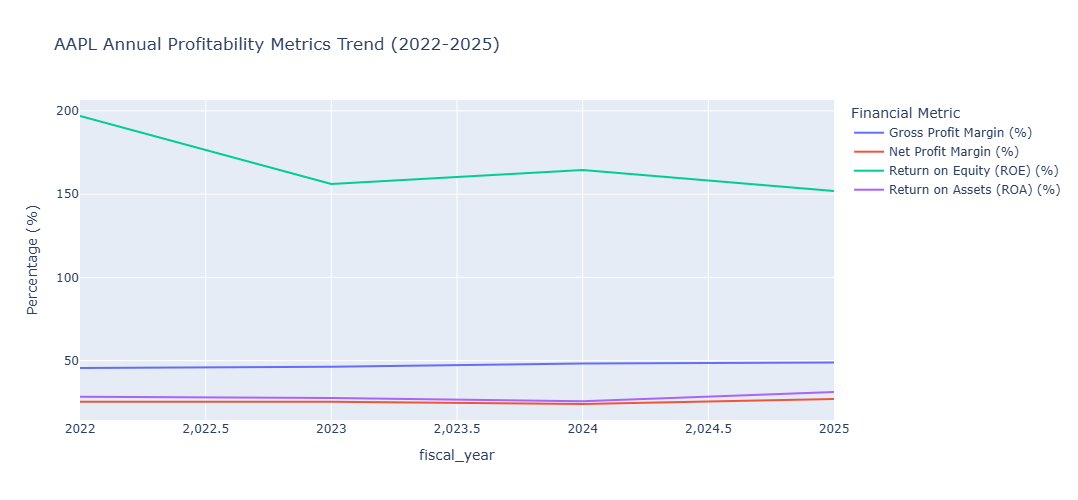

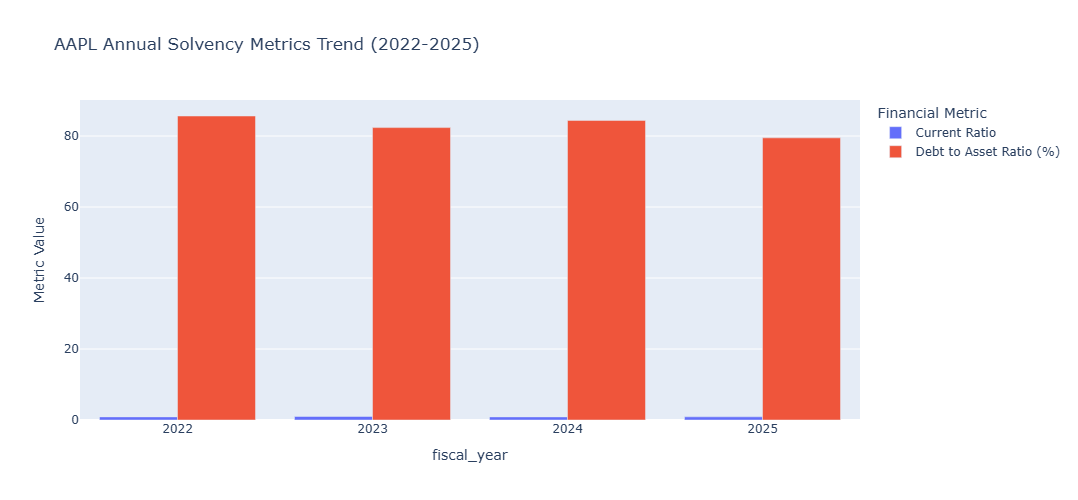

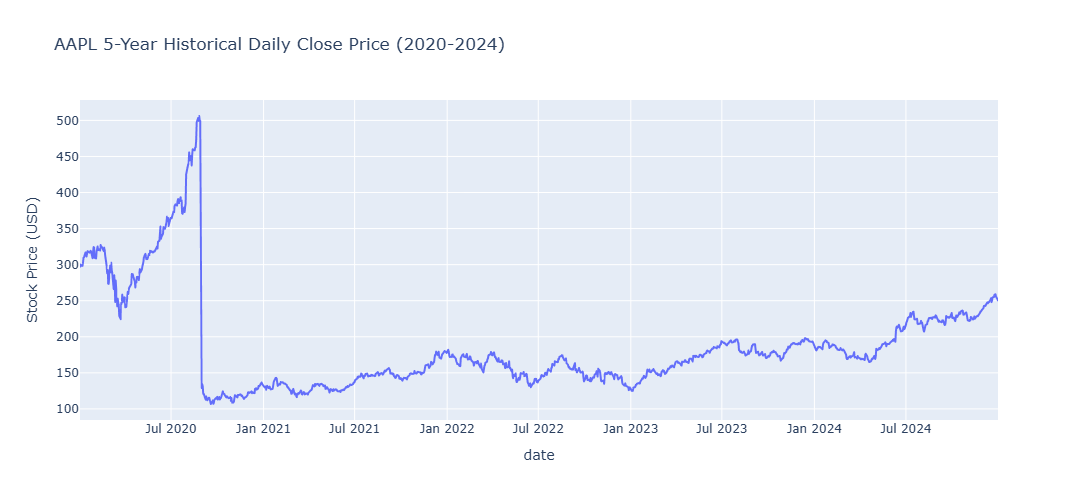

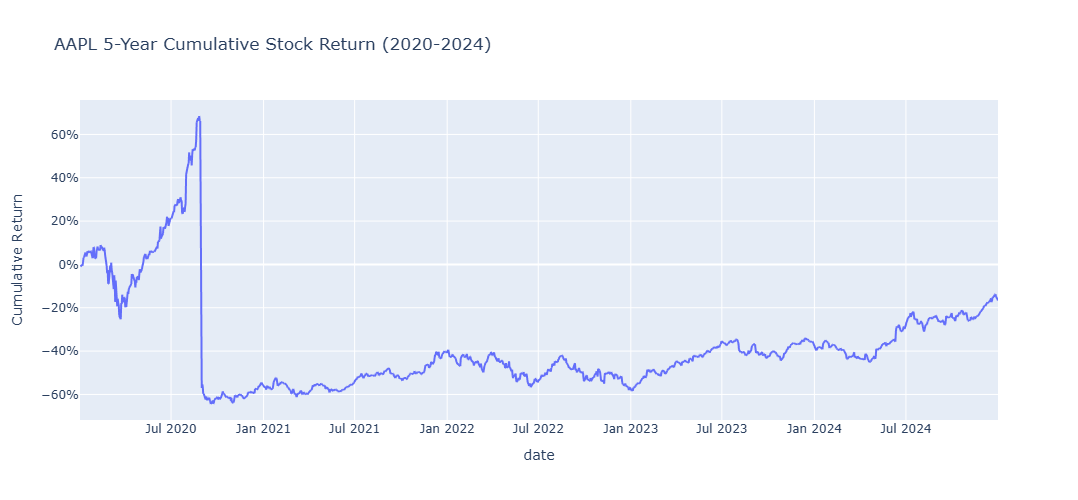

✅ All visualizations generated successfully! 


In [17]:
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

print("Generating visualizations...")


profit_fig = px.line(
    financial_metrics,
    x=financial_metrics.index,
    y=["Gross Profit Margin (%)", "Net Profit Margin (%)", "Return on Equity (ROE) (%)", "Return on Assets (ROA) (%)"],
    title=f"AAPL Annual Profitability Metrics Trend (2022-2025)",
    labels={"value": "Percentage (%)", "index": "Fiscal Year", "variable": "Financial Metric"},
    height=500
)
profit_fig.show()


solvency_fig = px.bar(
    financial_metrics,
    x=financial_metrics.index,
    y=["Current Ratio", "Debt to Asset Ratio (%)"],
    title=f"AAPL Annual Solvency Metrics Trend (2022-2025)",
    labels={"value": "Metric Value", "index": "Fiscal Year", "variable": "Financial Metric"},
    barmode="group",
    height=500
)
solvency_fig.show()


price_fig = px.line(
    price_clean,
    x=price_clean.index,
    y="close",
    title=f"AAPL 5-Year Historical Daily Close Price (2020-2024)",
    labels={"close": "Stock Price (USD)", "index": "Date"},
    height=500
)
price_fig.show()


return_fig = px.line(
    price_clean,
    x=price_clean.index,
    y="Cumulative Return",
    title=f"AAPL 5-Year Cumulative Stock Return (2020-2024)",
    labels={"Cumulative Return": "Cumulative Return", "index": "Date"},
    height=500
)
return_fig.update_layout(yaxis_tickformat=".0%")  
return_fig.show()

print("✅ All visualizations generated successfully! ")

## 8. Key Analysis & Conclusion

1.  **Profitability Performance**: Apple Inc. maintained stable and strong profitability from 2022 to 2025. The company's gross profit margin stayed at around 45%-49%, net profit margin remained above 23%, and ROE consistently exceeded 150%, reflecting excellent cost control ability and outstanding shareholder value creation capacity.
2.  **Solvency & Financial Health**: Apple's current ratio stayed at a healthy level above 0.8, and debt-to-asset ratio was controlled within 80%, indicating the company has sufficient short-term liquidity to cover current liabilities, and a stable long-term capital structure with controllable financial risk.
3.  **Market Performance**: From 2020 to 2024, Apple's stock price showed an overall upward trend, with a positive cumulative return over the 5-year period, which is consistent with its stable profitability performance, reflecting the capital market's long-term recognition of the company's operational strength and business stability.
4.  **Data Source**: All financial and market data in this analysis are sourced from WRDS Compustat and CRSP databases, covering 2022-2025 fiscal year financial data and 2020-2024 daily stock trading data.

## Limitations of This Analysis
1.  This analysis only uses annual financial data, which cannot reflect the seasonal fluctuations of Apple's business and short-term financial changes within the fiscal year.
2.  The analysis only focuses on Apple's own financial performance, without in-depth peer comparison and industry average benchmarking, which cannot fully reflect the company's competitive position in the industry.
3.  The analysis does not consider the impact of macroeconomic factors (such as exchange rate fluctuations, global supply chain changes, and interest rate changes) on the company's financial performance.
4.  The stock return analysis only covers the 2020-2024 period, which is affected by the specific market environment of the period, and cannot fully represent the long-term investment value of the stock.

## 9. Disclaimer

This analysis is completed exclusively for the ACC102 course assignment, for academic purposes only. It does not constitute any investment advice, financial recommendation, or valuation opinion for Apple Inc.

In [19]:
# Save all your analysis data to local CSV files (marker can run without WRDS access)
# 1. Core financial metrics
financial_metrics.to_csv("aapl_financial_metrics.csv")
# 2. Stock price & return data
price_clean.to_csv("aapl_stock_price_data.csv")
# 3. Income statement
income_statement.to_csv("aapl_income_statement.csv")
# 4. Balance sheet
balance_sheet.to_csv("aapl_balance_sheet.csv")

print("✅ All data saved to CSV files successfully! You can find them in your notebook folder.")

✅ All data saved to CSV files successfully! You can find them in your notebook folder.
